## Байесовская линейная регрессия с библиотекой PyMC

В этой практике рассмотрим PyMC для байесовской линейной регрессии с оценкой апостериорных распределений вероятностей.

In [1]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Давайте создадим некоторые переменные для нашей регрессии. Наши истинные значния:
* $\alpha = 1$
* $\sigma = 1$
* $\beta = 2.5$

Наша итоговая переменная будет расчитана по:
$$ Y = \alpha + \beta_1 X + N(0,\sigma).$$

In [2]:
# фиксируем сид
np.random.seed(42)

# Задаем значения параметров
alpha, sigma = 1, 1
beta = [2.5]

# Размер датасета
size = 1000

# Генерируем вектора признаков
X = np.random.randn(size)

# Считаем
Y = alpha + beta * X + np.random.randn(size)*sigma

отрисовка

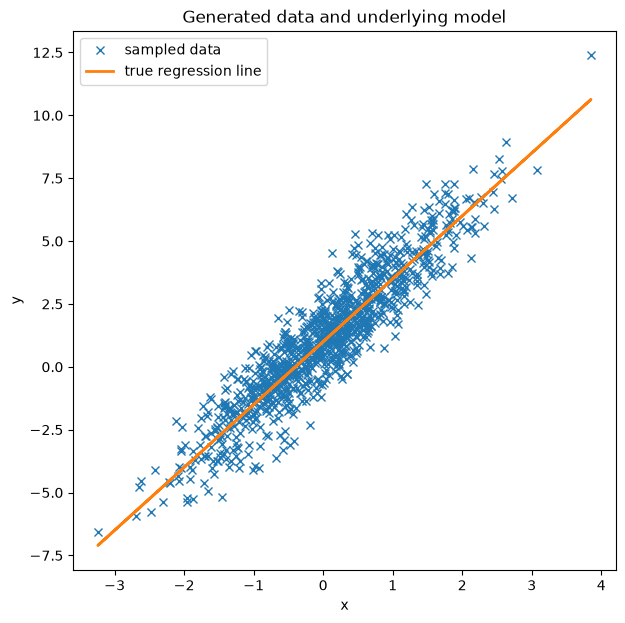

In [3]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel="x", ylabel="y", title="Generated data and underlying model")
ax.plot(X, Y, "x", label="sampled data")
ax.plot(X, alpha + beta * X, label="true regression line", lw=2.0)
plt.legend(loc=0);

Теперь построим модель.

Априорные распределения:
* $\alpha \sim \mathcal{N}(\mu=0,\sigma=10)$
* $\beta[i] \sim \mathcal{N}(\mu=0,\sigma=10)$, where $i=1$
* $\sigma \sim \textrm{half-normal}(\sigma=1)$

Определим ожидаемое значение:
\begin{equation}
  \text{Y} = \alpha + \beta*X
\end{equation}

Байесовцы придерживаются вероятностного взгляда на мир и выражают эту модель в терминах вероятностных распределений. Нашу приведенную выше линейную регрессию можно переписать, чтобы получить:

\begin{equation}
  \text{Y}\sim \mathcal{N}(\mu=\mu,\sigma=\sigma).
\end{equation}

In [4]:
basic_model = pm.Model()

with basic_model:

    # Приоры для неизвестных параметров модели 
    alpha = pm.Normal('alpha', mu=0, sigma=100) #intercept
    beta = pm.Normal('beta', mu=0, sigma=100) #slope
    sigma = pm.HalfNormal('sigma', sigma=100)

    # Ожидаемое значение переменной
    mu = alpha + beta * X

    # Вероятность (выборочное распределение) наблюдений / Likelihood (sampling distribution) of observations
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=Y)

    # Получаем 5000 объектов из апостериорного распределения
    linear_trace = pm.sample(5000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\Lib\site-packages\rich\live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1467 seconds.


In [5]:
basic_model

     alpha ~ Normal(0, 100)
      beta ~ Normal(0, 100)
     sigma ~ HalfNormal(0, 100)
likelihood ~ Normal(f(alpha, beta), sigma)

In [6]:
pm.traceplot(linear_trace, figsize = (12, 12))

AttributeError: module 'pymc' has no attribute 'traceplot'

traceplot - это стандартный хороший способ просмотра апостериорных распределений вероятностей

Got error No model on context stack. trying to find log_likelihood in translation.
/Users/y.mochalova/opt/anaconda3/lib/python3.8/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


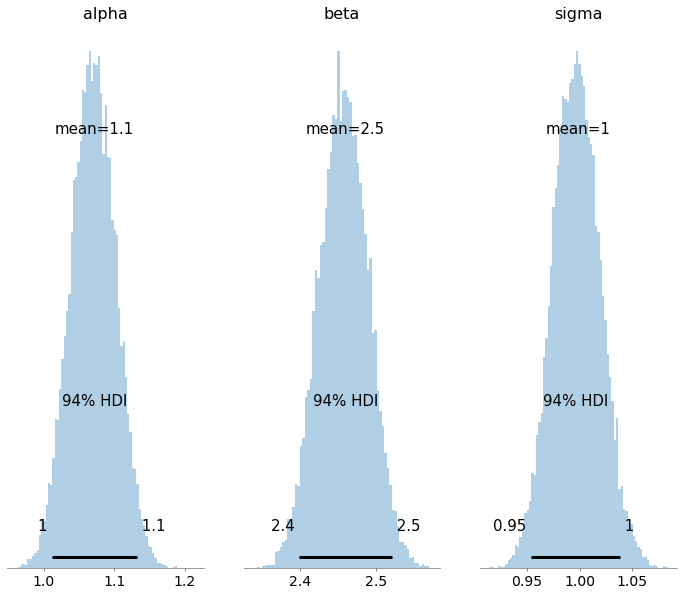

In [ ]:
pm.plot_posterior(linear_trace, figsize = (12, 10), kind="hist");

Также есть встроенная функция сводки.

In [ ]:
pm.summary(linear_trace).round(2)

Got error No model on context stack. trying to find log_likelihood in translation.
/Users/y.mochalova/opt/anaconda3/lib/python3.8/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.07,0.03,1.01,1.13,0.0,0.0,27513.0,15097.0,1.0
beta,2.46,0.03,2.40,2.52,0.0,0.0,28027.0,14553.0,1.0
sigma,1.00,0.02,0.95,1.04,0.0,0.0,28003.0,14839.0,1.0


/Users/y.mochalova/opt/anaconda3/lib/python3.8/site-packages/pymc3/plots/posteriorplot.py:59: DeprecationWarning: The `plot_posterior_predictive_glm` function will migrate to Arviz in a future release. 
Keep up to date with `ArviZ <https://arviz-devs.github.io/arviz/>`_ for future updates.
  warnings.warn(


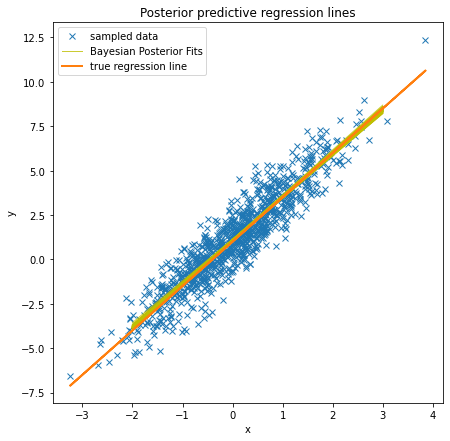

In [ ]:
plt.figure(figsize=(7, 7))
plt.plot(X, Y, "x", label="sampled data")
pm.plot_posterior_predictive_glm(linear_trace, samples = 100, eval=np.linspace(-2, 3, 50), linewidth = 1, 
                                 color = 'y', alpha = 0.8, label = 'Bayesian Posterior Fits',
                                lm = lambda x, sample: sample['alpha'] + sample['beta'] * x);

plt.plot(X, alpha + beta * X, label="true regression line", lw=2.0)
plt.title("Posterior predictive regression lines")
plt.legend(loc=0)
plt.xlabel("x")
plt.ylabel("y");

In [ ]:
alpha = linear_trace['alpha'].mean() 
beta = linear_trace['beta'].mean()